In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.datasets import load_rossi

df = load_rossi()
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)

   week  arrest  fin  age  race  wexp  mar  paro  prio
0    20       1    0   27     1     0    0     1     3
1    17       1    0   18     1     0    0     1     8
2    25       1    0   19     0     1    0     1    13
3    52       0    1   23     1     1    1     1     1
4    52       0    0   19     0     1    0     1     3

Columns: ['week', 'arrest', 'fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']

Shape: (432, 9)



--- CoxPH Summary ---
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
fin       -0.379422   0.684257  0.191379       -0.754519       -0.004325   
age       -0.057438   0.944181  0.021999       -0.100556       -0.014320   
race       0.313900   1.368753  0.307993       -0.289755        0.917555   
wexp      -0.149796   0.860884  0.212224       -0.565748        0.266156   
mar       -0.433704   0.648104  0.381868       -1.182152        0.314744   
paro      -0.084871   0.918631  0.195757       -0.468547        0.298805   
prio       0.091497   1.095814  0.028649        0.035347        0.147647   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
fin                   0.470237             0.995684     0.0 -1.982565   
age                   0.904335             0.985782     0.0 -2.610869   


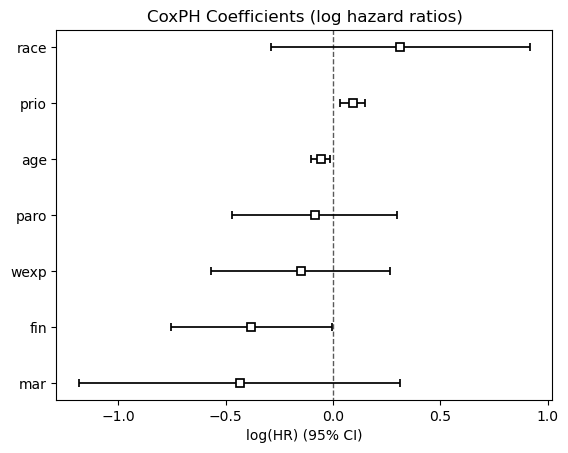

<Figure size 640x480 with 0 Axes>

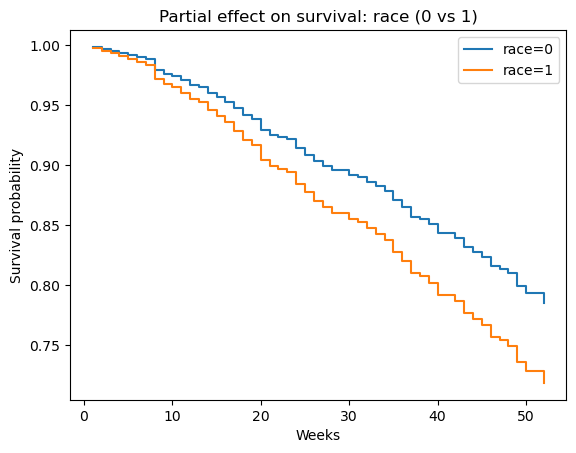

<Figure size 640x480 with 0 Axes>

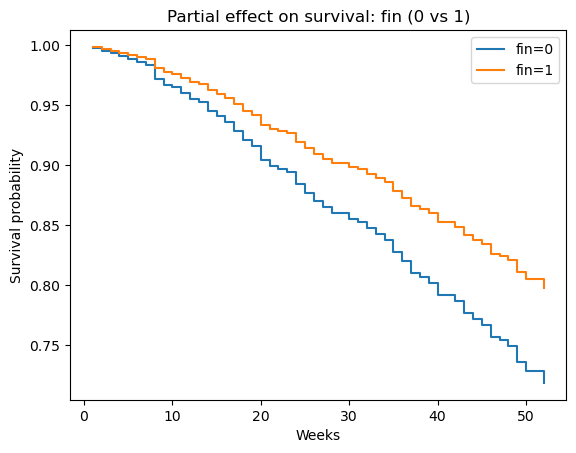

/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_97511/3212016648.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, g in df_km.groupby("age_group", dropna=True):


ValueError: Values must be numeric: no strings, datetimes, objects, etc.

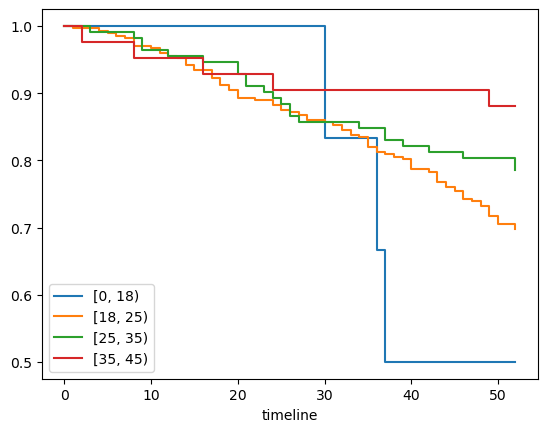

In [2]:
#Fit Cox Proportional Hazards
cph = CoxPHFitter()
cph.fit(df, duration_col="week", event_col="arrest")

print("\n--- CoxPH Summary ---")
print(cph.summary)

ax = cph.plot()
ax.set_title("CoxPH Coefficients (log hazard ratios)")
plt.show()

plt.figure()
cph.plot_partial_effects_on_outcome(
    covariates="race",
    values=[0, 1],
    plot_baseline=False
)
plt.title("Partial effect on survival: race (0 vs 1)")
plt.xlabel("Weeks")
plt.ylabel("Survival probability")
plt.show()

#Another example: fin=0 vs fin=1
plt.figure()
cph.plot_partial_effects_on_outcome(
    covariates="fin",
    values=[0, 1],
    plot_baseline=False
)
plt.title("Partial effect on survival: fin (0 vs 1)")
plt.xlabel("Weeks")
plt.ylabel("Survival probability")
plt.show()

df_km = df.copy()
df_km["age_group"] = pd.cut(
    df_km["age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 200],
    right=False
)

kmf = KaplanMeierFitter()

plt.figure()
for group, g in df_km.groupby("age_group", dropna=True):
    kmf.fit(durations=g["week"], event_observed=g["arrest"], label=str(group))
    kmf.plot(ci_show=False)

plt.title("Kaplan-Meier survival curves by age group")
plt.xlabel("Weeks")
plt.ylabel("Survival probability")
plt.legend(title="Age group")
plt.show()

covars = [c for c in df.columns if c not in ["week", "arrest"]]

baseline = df[covars].mean(numeric_only=True)

X2 = pd.DataFrame([baseline, baseline]).astype(float)

X2.loc[0, "fin"] = 1
X2.loc[0, "age"] = 35
X2.loc[0, "prio"] = 1
X2.loc[0, "race"] = 1

X2.loc[1, "fin"] = 0
X2.loc[1, "age"] = 50
X2.loc[1, "prio"] = 4
X2.loc[1, "race"] = 1

surv = cph.predict_survival_function(X2)

plt.figure()
surv.iloc[:, 0].plot(label="Person A")
surv.iloc[:, 1].plot(label="Person B")
plt.title("Predicted survival functions (two example individuals)")
plt.xlabel("Weeks")
plt.ylabel("Survival probability")
plt.legend()
plt.show()

median_times = cph.predict_median(df[covars])
print("\n--- Median survival times (first 10) ---")
print(median_times.head(10))

median_times = np.asarray(median_times)
finite = median_times[np.isfinite(median_times)]

plt.figure()
plt.hist(finite, bins=30)
plt.title("Distribution of predicted median survival times (finite only)")
plt.xlabel("Weeks")
plt.ylabel("Count")
plt.show()